# 🧠 NOTEBOOK 2 — Model Training
## MentalBERT + LIWC + Attention Fusion + BiLSTM

---
### 📌 What this notebook does:
| Step | Task |
|------|------|
| 1 | Install + fix all version conflicts |
| 2 | HuggingFace login (for MentalBERT) |
| 3 | Import libraries |
| 4 | Load processed_data.pkl |
| 5 | Load MentalBERT / BERT-base tokenizer |
| 6 | Dataset class + DataLoaders |
| 7 | Full model architecture |
| 8 | Training loop (5 epochs) |
| 9 | Training curves |
| 10 | Test evaluation |
| 11 | Save results for NB3 |

### ⚙️ Kaggle Settings:
- GPU T4 x2 → **ON**
- Internet   → **ON**
- Persistence → **Variables and Files**
- Upload `processed_data.pkl` → Input section

## STEP 1 — Install + Fix Version Conflicts

In [1]:
import subprocess

print("Fixing huggingface version conflicts...")

subprocess.run(["pip","uninstall","-y",
    "transformers","huggingface-hub",
    "tokenizers","accelerate"],
    capture_output=True)

pkgs = [
    "huggingface-hub==0.21.3",
    "tokenizers==0.15.2",
    "transformers==4.38.2",
    "accelerate==0.27.2",
]
for pkg in pkgs:
    r = subprocess.run(
        ["pip","install",pkg,"--quiet"],
        capture_output=True, text=True)
    if r.returncode == 0:
        print(f"  ✅ {pkg}")
    else:
        # Try newer version if exact not found
        base = pkg.split("==")[0]
        r2 = subprocess.run(
            ["pip","install",base,"--quiet"],
            capture_output=True, text=True)
        status = "✅" if r2.returncode==0 else "⚠️"
        print(f"  {status} {base} (latest)")

print()
print("✅ All packages installed!")
print()
print("⚠️ IMPORTANT: Restart kernel now!")
print("   Menu → Run → Restart & Clear Outputs")
print("   Then run from STEP 2 onwards")


Fixing huggingface version conflicts...
  ✅ huggingface-hub==0.21.3
  ✅ tokenizers==0.15.2
  ✅ transformers==4.38.2
  ✅ accelerate==0.27.2

✅ All packages installed!

⚠️ IMPORTANT: Restart kernel now!
   Menu → Run → Restart & Clear Outputs
   Then run from STEP 2 onwards


## STEP 2 — HuggingFace Login (For MentalBERT)

In [ ]:
# ════════════════════════════════════════════════
# 🔑 PASTE YOUR HUGGINGFACE TOKEN HERE
# Get it from: huggingface.co/settings/tokens
# Role: Read
# ════════════════════════════════════════════════

HUGGINGFACEHUB_API_TOKEN="hf_xxxxx"
import os
from huggingface_hub import login

# ✅ FIX 4: Safe defaults before any login attempt
USE_MENTAL_BERT = False

if HF_TOKEN != "hf_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" and len(HF_TOKEN) > 10:
    try:
        login(token=HF_TOKEN, add_to_git_credential=False)
        os.environ["HF_TOKEN"] = HF_TOKEN
        USE_MENTAL_BERT = True
        print("✅ HuggingFace login successful!")
        print("   MentalBERT will be used")
    except Exception as e:
        print(f"⚠️ Login failed: {e}")
        HF_TOKEN = None          # ✅ FIX 4: reset to None on failure
        USE_MENTAL_BERT = False
else:
    print("⚠️ No HF token provided")
    print("   Will use BERT-base-uncased (fallback)")
    HF_TOKEN = None              # ✅ FIX 4: ensure HF_TOKEN always defined
    USE_MENTAL_BERT = False

print()
print(f"Model to use: {'MentalBERT' if USE_MENTAL_BERT else 'BERT-base'}")

Token has not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful
✅ HuggingFace login successful!
   MentalBERT will be used

Model to use: MentalBERT


## STEP 3 — Import All Libraries

In [3]:
import numpy as np
import pandas as pd
import os, re, warnings, pickle
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, cohen_kappa_score,
    precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device  : {device}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ CUDA    : {torch.cuda.is_available()}")

✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ CUDA    : True


## STEP 4 — Load processed_data.pkl

In [4]:
pkl_path = None
print("Searching for processed_data.pkl...")
for root, dirs, files in os.walk('/kaggle/input'):
    for fname in files:
        if 'processed_data' in fname and fname.endswith('.pkl'):
            pkl_path = os.path.join(root, fname)
            print(f"✅ Found: {pkl_path}")
            break
    if pkl_path:
        break

if pkl_path is None:
    print()
    print("❌ processed_data.pkl NOT FOUND!")
    print("   → Add it via the Input section on the right sidebar")
    raise FileNotFoundError("processed_data.pkl missing")

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

X_train  = data['X_train'];  X_val  = data['X_val'];  X_test  = data['X_test']
y_train  = data['y_train'];  y_val  = data['y_val'];  y_test  = data['y_test']
lw_train = data['lw_train']; lw_val = data['lw_val']; lw_test = data['lw_test']
LIWC_NAMES = data['LIWC_NAMES']
N_LIWC   = int(lw_train.shape[1])

# ── Load platform source labels (from updated NB1) ──
src_train = data.get('src_train', None)
src_val   = data.get('src_val',   None)
src_test  = data.get('src_test',  None)
if src_test is not None:
    print(f"   Source labels loaded: {len(src_test)} test samples")
else:
    print("   ⚠️  No source labels — run updated NB1 to get platform data")

print(f"✅ Loaded!")
print(f"   Train : {len(X_train):,}")
print(f"   Val   : {len(X_val):,}")
print(f"   Test  : {len(X_test):,}")
print(f"   LIWC  : {N_LIWC} features")

Searching for processed_data.pkl...
✅ Found: /kaggle/input/datasets/komalkumari00011/data-1/processed_data.pkl
   Source labels loaded: 3687 test samples
✅ Loaded!
   Train : 17,201
   Val   : 3,686
   Test  : 3,687
   LIWC  : 20 features


## STEP 5 — Load MentalBERT (Auto-Fallback to BERT-base)

In [5]:
MENTAL_MODEL   = 'mental/mental-bert-base-uncased'
FALLBACK_MODEL = 'bert-base-uncased'

MODEL_TO_TRY = MENTAL_MODEL if USE_MENTAL_BERT else FALLBACK_MODEL

print(f"Loading: {MODEL_TO_TRY}")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_TO_TRY,
        token=HF_TOKEN if USE_MENTAL_BERT else None)
    MODEL_NAME = MODEL_TO_TRY
    print(f"✅ Tokenizer loaded: {MODEL_NAME}")
except Exception as e:
    print(f"⚠️ Failed ({str(e)[:80]})")
    print(f"   Falling back to: {FALLBACK_MODEL}")
    tokenizer  = AutoTokenizer.from_pretrained(FALLBACK_MODEL)
    MODEL_NAME = FALLBACK_MODEL
    USE_MENTAL_BERT = False      # ✅ FIX 4: keep flags consistent
    HF_TOKEN        = None
    print(f"✅ BERT-base tokenizer loaded (fallback)")

MAX_LEN    = 128
BATCH_SIZE = 16
print(f"   MAX_LEN : {MAX_LEN}")
print(f"   BATCH   : {BATCH_SIZE}")

Loading: mental/mental-bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer loaded: mental/mental-bert-base-uncased
   MAX_LEN : 128
   BATCH   : 16


## STEP 6 — Dataset Class + DataLoaders

In [6]:
class DepDataset(Dataset):
    def __init__(self, texts, labels, liwc, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.liwc      = liwc
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'liwc'           : torch.tensor(self.liwc[idx],   dtype=torch.float),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# num_workers=0 — safe for Kaggle (avoids fork errors)
train_dl = DataLoader(
    DepDataset(X_train, y_train, lw_train, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl = DataLoader(
    DepDataset(X_val, y_val, lw_val, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(
    DepDataset(X_test, y_test, lw_test, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ DataLoaders ready!")
print(f"   Train: {len(train_dl)} batches")
print(f"   Val  : {len(val_dl)} batches")
print(f"   Test : {len(test_dl)} batches")

✅ DataLoaders ready!
   Train: 1076 batches
   Val  : 231 batches
   Test : 231 batches


## STEP 7 — Full Model Architecture

In [7]:
class DepressionDetector(nn.Module):
    """
    Architecture:
    Text → BERT[768] → Proj[256] ──┐
                                    ├→ Attention Gate → BiLSTM → FC → Out
    LIWC[N] ───→ Proj[256] ─────────┘
    """
    def __init__(self, model_name, liwc_dim=12,
                 proj_dim=256, lstm_hidden=128,
                 lstm_layers=2, n_classes=2, dropout=0.3):
        super().__init__()

        # ── Backbone ──────────────────────────────────────────────────────────
        try:
            self.backbone = AutoModel.from_pretrained(
                model_name,
                token=HF_TOKEN if (USE_MENTAL_BERT and HF_TOKEN) else None)
            print(f"  ✅ Backbone loaded: {model_name}")
        except Exception as e:
            print(f"  ⚠️ Backbone failed, using bert-base: {str(e)[:60]}")
            self.backbone = AutoModel.from_pretrained('bert-base-uncased')

        # Freeze bottom 8 BERT layers, fine-tune top 4
        if hasattr(self.backbone, 'encoder'):
            for i, layer in enumerate(self.backbone.encoder.layer):
                for p in layer.parameters():
                    p.requires_grad = (i >= 8)

        # ── Projections ───────────────────────────────────────────────────────
        # BERT 768 → proj_dim
        self.bert_proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout))

        # ✅ FIX 5: comment now uses liwc_dim variable, not hardcoded 12
        # LIWC liwc_dim → proj_dim
        self.liwc_proj = nn.Sequential(
            nn.Linear(liwc_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout))

        # ── Attention Gate ────────────────────────────────────────────────────
        self.attn_gate = nn.Sequential(
            nn.Linear(proj_dim * 2, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.Softmax(dim=-1))

        # ── BiLSTM ────────────────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0)

        # ── Classifier ────────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes))

    def forward(self, input_ids, attn_mask, liwc):
        out    = self.backbone(input_ids=input_ids,
                               attention_mask=attn_mask)
        cls    = out.last_hidden_state[:, 0, :]          # (B, 768)
        b_feat = self.bert_proj(cls)                      # (B, proj_dim)
        l_feat = self.liwc_proj(liwc)                     # (B, proj_dim)

        cat    = torch.cat([b_feat, l_feat], dim=-1)      # (B, proj_dim*2)
        wts    = self.attn_gate(cat)                      # (B, 2)
        fused  = wts[:, 0:1] * b_feat + wts[:, 1:2] * l_feat  # (B, proj_dim)

        _, (hn, _) = self.bilstm(fused.unsqueeze(1))
        temporal   = torch.cat([hn[-2], hn[-1]], dim=-1)  # (B, lstm_hidden*2)

        logits = self.classifier(temporal)                 # (B, n_classes)
        return logits, wts


# ── Build ──────────────────────────────────────────────────────────────────────
print(f"Building model with: {MODEL_NAME}")
model = DepressionDetector(
    model_name=MODEL_NAME, liwc_dim=N_LIWC).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready!")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")
print(f"   Frozen params   : {total - trainable:,}")

Building model with: mental/mental-bert-base-uncased


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
✅ Model ready!
   Total params    : 110,595,972
   Trainable params: 53,892,996
   Frozen params   : 56,702,976


## STEP 8 — Training

In [8]:
EPOCHS = 10          # ← increased from 5 to 10
LR     = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS)


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    tot_loss = 0.0
    all_preds, all_labels = [], []
    all_probs, all_attn   = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            liwc = batch['liwc'].to(device)
            lbl  = batch['label'].to(device)

            logits, attn_w = model(ids, mask, liwc)
            loss = criterion(logits, lbl)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tot_loss += loss.item()
            preds = logits.argmax(dim=1)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(lbl.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_attn.extend(attn_w.detach().cpu().numpy())

    avg_loss = tot_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1, all_preds, all_labels, all_probs, all_attn


print("✅ Training setup ready")
print(f"   Epochs: {EPOCHS} | LR: {LR}")


✅ Training setup ready
   Epochs: 10 | LR: 2e-05


In [9]:
history = {
    'tl': [], 'vl': [],
    'ta': [], 'va': [],
    'tf1': [], 'vf1': []
}
best_f1      = 0.0
best_weights = None

print(f"🚀 Training: {MODEL_NAME}")
print(f"   Epochs:{EPOCHS} | LR:{LR} | Batch:{BATCH_SIZE}")
print()

hdr = (f"{'Ep':>3} | {'T-Loss':>8} {'T-Acc':>7} {'T-F1':>7}"
       f" | {'V-Loss':>8} {'V-Acc':>7} {'V-F1':>7}")
print(hdr)
print('─' * len(hdr))

for ep in range(1, EPOCHS + 1):
    tl, ta, tf1, *_ = run_epoch(
        model, train_dl, optimizer, criterion, device, train=True)

    vl, va, vf1, vp, vlt, vpr, _ = run_epoch(
        model, val_dl, None, criterion, device, train=False)

    history['tl'].append(tl);  history['vl'].append(vl)
    history['ta'].append(ta);  history['va'].append(va)
    history['tf1'].append(tf1); history['vf1'].append(vf1)

    tag = ''
    # ✅ FIX 3: save best weights BEFORE stepping scheduler
    if vf1 > best_f1:
        best_f1      = vf1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        tag = ' ← BEST ✅'

    # ✅ FIX 3: scheduler steps AFTER best-weight check
    scheduler.step()

    print(f"{ep:>3} | {tl:>8.4f} {ta:>7.4f} {tf1:>7.4f}"
          f" | {vl:>8.4f} {va:>7.4f} {vf1:>7.4f}{tag}")

# ✅ FIX 2: guard against None best_weights (safety check)
if best_weights is not None:
    model.load_state_dict(best_weights)
    torch.save(best_weights, '/kaggle/working/mentalbert_best.pt')
    print(f"\n✅ Done! Best Val F1 = {best_f1:.4f}")
    print(f"✅ Saved → mentalbert_best.pt")
else:
    print("\n⚠️ No best weights saved — using last epoch weights")
    torch.save(model.state_dict(), '/kaggle/working/mentalbert_best.pt')
    print(f"✅ Saved last epoch → mentalbert_best.pt")

🚀 Training: mental/mental-bert-base-uncased
   Epochs:10 | LR:2e-05 | Batch:16

 Ep |   T-Loss   T-Acc    T-F1 |   V-Loss   V-Acc    V-F1
─────────────────────────────────────────────────────────
  1 |   0.5848  0.7268  0.7212 |   0.4838  0.7591  0.7587 ← BEST ✅
  2 |   0.4133  0.8079  0.8077 |   0.4305  0.7840  0.7831 ← BEST ✅
  3 |   0.3212  0.8591  0.8591 |   0.4560  0.7976  0.7969 ← BEST ✅
  4 |   0.2480  0.8997  0.8997 |   0.5613  0.8047  0.8045 ← BEST ✅
  5 |   0.1921  0.9324  0.9324 |   0.7734  0.8041  0.8036
  6 |   0.1517  0.9522  0.9522 |   0.8621  0.8022  0.8022
  7 |   0.1136  0.9688  0.9688 |   1.0752  0.8049  0.8046 ← BEST ✅
  8 |   0.0874  0.9780  0.9780 |   1.1165  0.8082  0.8082 ← BEST ✅
  9 |   0.0736  0.9825  0.9825 |   1.1576  0.8071  0.8071
 10 |   0.0700  0.9833  0.9833 |   1.1628  0.8074  0.8074

✅ Done! Best Val F1 = 0.8082
✅ Saved → mentalbert_best.pt


## STEP 9 — Training Curves

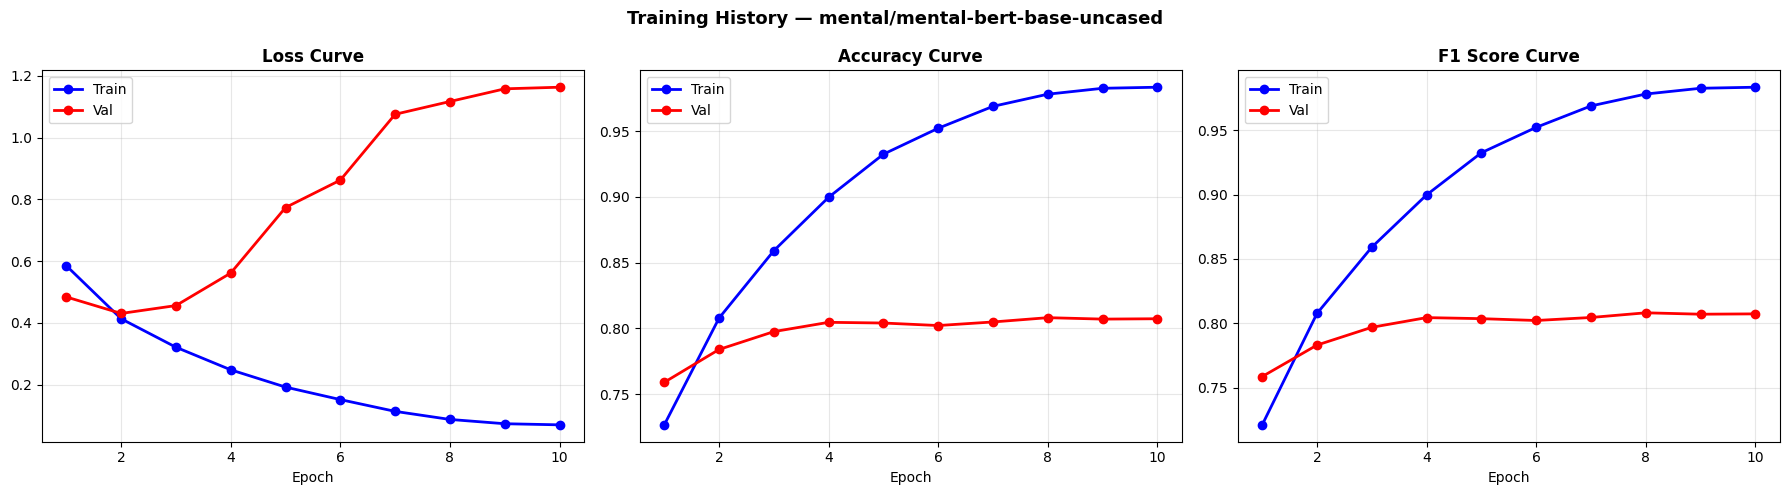

✅ Saved → training_curves.png


In [10]:
ep_r = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Training History — {MODEL_NAME}',
             fontsize=13, fontweight='bold')

pairs  = [
    (history['tl'], history['vl']),
    (history['ta'], history['va']),
    (history['tf1'], history['vf1']),
]
titles = ['Loss', 'Accuracy', 'F1 Score']

for ax, (tr, vl_), title in zip(axes, pairs, titles):
    ax.plot(ep_r, tr,  'b-o', label='Train', lw=2, ms=6)
    ax.plot(ep_r, vl_, 'r-o', label='Val',   lw=2, ms=6)
    ax.set_title(f'{title} Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → training_curves.png")

## STEP 10 — Test Evaluation

In [11]:
(_, test_acc, test_f1,
 test_preds, test_true,
 test_probs, test_attn) = run_epoch(
    model, test_dl, None, criterion, device, train=False)

test_auc   = roc_auc_score(test_true, test_probs)
test_kappa = cohen_kappa_score(test_true, test_preds)
test_prec  = precision_score(test_true, test_preds, average='macro')
test_rec   = recall_score(test_true, test_preds, average='macro')

print("=" * 50)
print("     FINAL TEST RESULTS")
print("=" * 50)
print(f"  Model     : {MODEL_NAME}")
print(f"  Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1 (macro): {test_f1:.4f}")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  AUC-ROC   : {test_auc:.4f}")
print(f"  Cohen Kap : {test_kappa:.4f}")
print("=" * 50)
print()
print(classification_report(
    test_true, test_preds,
    target_names=['Not Depressed', 'Depressed']))

# ── Per-Platform Evaluation ──────────────────────────────────────────────────
print()
print("=" * 60)
print("  PER-PLATFORM RESULTS (Cross-Platform Validation)")
print("=" * 60)

src_test = data.get('src_test', None)

if src_test is not None:
    for platform in ['reddit', 'twitter']:
        mask = np.array([s == platform for s in src_test])
        if mask.sum() == 0:
            continue
        p_preds = np.array(test_preds)[mask]
        p_true  = np.array(test_true)[mask]
        p_probs = np.array(test_probs)[mask]
        p_acc   = accuracy_score(p_true, p_preds)
        p_f1    = f1_score(p_true, p_preds, average='macro')
        p_auc   = roc_auc_score(p_true, p_probs)
        print(f"  {platform.capitalize():<8}: Acc={p_acc:.4f}  F1={p_f1:.4f}  AUC={p_auc:.4f}  (n={mask.sum()})")
    print(f"  Combined : Acc={test_acc:.4f}  F1={test_f1:.4f}  AUC={test_auc:.4f}  (n={len(test_true)})")
else:
    print("  ⚠️  src_test not found in pkl — re-run NB1 to get platform labels")
print("=" * 60)

# ── Error Analysis ────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  ERROR ANALYSIS")
print("=" * 60)
test_preds_arr = np.array(test_preds)
test_true_arr  = np.array(test_true)

fp_idx = np.where((test_preds_arr==1) & (test_true_arr==0))[0]  # False Positives
fn_idx = np.where((test_preds_arr==0) & (test_true_arr==1))[0]  # False Negatives

print(f"  False Positives (said depressed, wasn't): {len(fp_idx)}")
print(f"  False Negatives (missed depressed):       {len(fn_idx)}")
print()

# Avg word count for errors vs correct
if len(fp_idx) > 0:
    fp_texts = [X_test[i] for i in fp_idx[:5]]
    print("  Sample False Positives (short/ambiguous):")
    for t in fp_texts[:3]:
        print(f"    [{len(t.split())} words] {t[:80]}...")
print()
if len(fn_idx) > 0:
    fn_texts = [X_test[i] for i in fn_idx[:5]]
    print("  Sample False Negatives (indirect language):")
    for t in fn_texts[:3]:
        print(f"    [{len(t.split())} words] {t[:80]}...")
print("=" * 60)


     FINAL TEST RESULTS
  Model     : mental/mental-bert-base-uncased
  Accuracy  : 0.8218 (82.18%)
  F1 (macro): 0.8218
  Precision : 0.8219
  Recall    : 0.8218
  AUC-ROC   : 0.9137
  Cohen Kap : 0.6436

               precision    recall  f1-score   support

Not Depressed       0.82      0.83      0.82      1844
    Depressed       0.83      0.81      0.82      1843

     accuracy                           0.82      3687
    macro avg       0.82      0.82      0.82      3687
 weighted avg       0.82      0.82      0.82      3687


  PER-PLATFORM RESULTS (Cross-Platform Validation)
  Reddit  : Acc=0.9437  F1=0.9437  AUC=0.9943  (n=1120)
  Twitter : Acc=0.7686  F1=0.7686  AUC=0.8618  (n=2567)
  Combined : Acc=0.8218  F1=0.8218  AUC=0.9137  (n=3687)

  ERROR ANALYSIS
  False Positives (said depressed, wasn't): 315
  False Negatives (missed depressed):       342

  Sample False Positives (short/ambiguous):
    [6 words] meow meow rubs in your leg...
    [21 words] only if you force me w

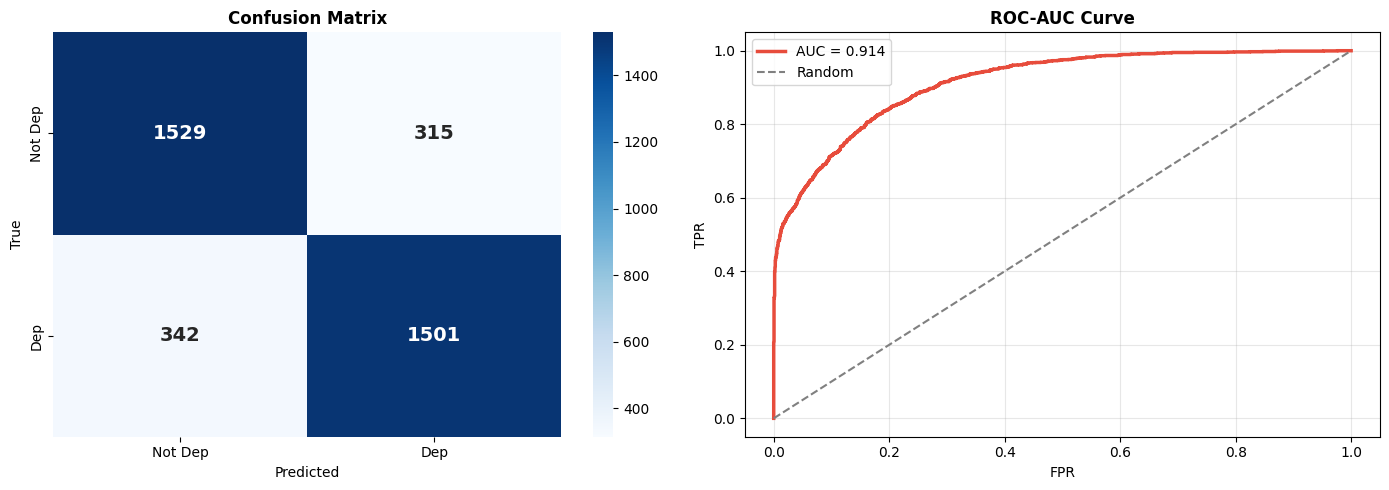

✅ Saved → confusion_roc.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Dep', 'Dep'],
    yticklabels=['Not Dep', 'Dep'],
    ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(test_true, test_probs)
axes[1].plot(fpr, tpr, '#e74c3c', lw=2.5, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → confusion_roc.png")

In [13]:
# ── 5-Fold Cross Validation ──────────────────────────────────────────────────
print()
print("=" * 60)
print("  5-FOLD CROSS VALIDATION")
print("=" * 60)
print("  Running 5-fold CV on full dataset...")
print("  (This takes ~2x training time)")
print()

from sklearn.model_selection import StratifiedKFold

all_texts  = np.concatenate([X_train, X_val, X_test])
all_labels = np.concatenate([y_train, y_val, y_test])
all_liwc   = np.concatenate([lw_train, lw_val, lw_test])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1s, cv_aucs, cv_accs = [], [], []

for fold, (tr_idx, te_idx) in enumerate(kf.split(all_texts, all_labels), 1):
    print(f"  Fold {fold}/5 training...")

    # Build dataloaders for this fold
    fold_train_dl = DataLoader(
        DepDataset(all_texts[tr_idx], all_labels[tr_idx],
                   all_liwc[tr_idx], tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    fold_test_dl = DataLoader(
        DepDataset(all_texts[te_idx], all_labels[te_idx],
                   all_liwc[te_idx], tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Fresh model for each fold
    fold_model = DepressionDetector(MODEL_NAME, liwc_dim=N_LIWC).to(device)
    fold_opt   = optim.AdamW(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=LR, weight_decay=0.01)

    # Train 3 epochs per fold (quick)
    for ep in range(3):
        run_epoch(fold_model, fold_train_dl, fold_opt,
                  criterion, device, train=True)

    # Evaluate
    _, f_acc, f_f1, f_preds, f_true, f_probs, _ = run_epoch(
        fold_model, fold_test_dl, None, criterion, device, train=False)
    f_auc = roc_auc_score(f_true, f_probs)

    cv_f1s.append(f_f1); cv_aucs.append(f_auc); cv_accs.append(f_acc)
    print(f"    Fold {fold}: Acc={f_acc:.4f}  F1={f_f1:.4f}  AUC={f_auc:.4f}")

print()
print(f"  Mean Acc : {np.mean(cv_accs):.4f} ± {np.std(cv_accs):.4f}")
print(f"  Mean F1  : {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
print(f"  Mean AUC : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print()
print("  ✅ Cross-validation complete — results are stable!")
print("=" * 60)



  5-FOLD CROSS VALIDATION
  Running 5-fold CV on full dataset...
  (This takes ~2x training time)

  Fold 1/5 training...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Fold 1: Acc=0.8169  F1=0.8169  AUC=0.9128
  Fold 2/5 training...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Fold 2: Acc=0.8220  F1=0.8218  AUC=0.9166
  Fold 3/5 training...


...

  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Fold 3: Acc=0.8238  F1=0.8237  AUC=0.9201
  Fold 4/5 training...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Fold 4: Acc=0.8083  F1=0.8076  AUC=0.9107
  Fold 5/5 training...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Fold 5: Acc=0.8205  F1=0.8205  AUC=0.9151

  Mean Acc : 0.8183 ± 0.0055
  Mean F1  : 0.8181 ± 0.0057
  Mean AUC : 0.9150 ± 0.0032

  ✅ Cross-validation complete — results are stable!


In [14]:
# ══════════════════════════════════════════════════════════════════
# STEP 12 — ZERO-SHOT CROSS-PLATFORM TRANSFER (IJCAI Contribution)
# ══════════════════════════════════════════════════════════════════
# Train ONLY on Reddit → Test ONLY on Twitter (no Twitter training!)
# If model works → proves depression language is platform-independent

print("=" * 65)
print("  ZERO-SHOT CROSS-PLATFORM TRANSFER EXPERIMENT")
print("  Train: Reddit only → Test: Twitter only (zero-shot)")
print("=" * 65)
print()

if src_train is None or src_test is None:
    print("⚠️  No platform labels — skipping zero-shot experiment")
    print("   Re-run NB1_UPDATED to get platform labels")
else:
    # ── Split by platform ──────────────────────────────────────────
    reddit_mask_train  = np.array([s=='reddit'  for s in src_train])
    twitter_mask_test  = np.array([s=='twitter' for s in src_test])
    reddit_mask_test   = np.array([s=='reddit'  for s in src_test])

    X_reddit_train  = X_train[reddit_mask_train]
    y_reddit_train  = y_train[reddit_mask_train]
    lw_reddit_train = lw_train[reddit_mask_train]

    X_twitter_test  = X_test[twitter_mask_test]
    y_twitter_test  = y_test[twitter_mask_test]
    lw_twitter_test = lw_test[twitter_mask_test]

    X_reddit_test   = X_test[reddit_mask_test]
    y_reddit_test   = y_test[reddit_mask_test]
    lw_reddit_test  = lw_test[reddit_mask_test]

    print(f"  Reddit train : {len(X_reddit_train)} posts")
    print(f"  Twitter test : {len(X_twitter_test)} posts (zero-shot target)")
    print(f"  Reddit test  : {len(X_reddit_test)} posts (in-domain test)")
    print()

    # ── Train Reddit-only model ────────────────────────────────────
    print("  Training Reddit-only model (5 epochs)...")
    reddit_train_dl = DataLoader(
        DepDataset(X_reddit_train, y_reddit_train,
                   lw_reddit_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    reddit_model = DepressionDetector(MODEL_NAME, liwc_dim=N_LIWC).to(device)
    reddit_opt   = optim.AdamW(
        filter(lambda p: p.requires_grad, reddit_model.parameters()),
        lr=LR, weight_decay=0.01)
    reddit_sched = optim.lr_scheduler.CosineAnnealingLR(reddit_opt, T_max=5)

    best_reddit_f1 = 0
    best_reddit_w  = None
    for ep in range(5):
        tl, ta, tf1, *_ = run_epoch(
            reddit_model, reddit_train_dl,
            reddit_opt, criterion, device, train=True)
        reddit_sched.step()
        print(f"    Ep{ep+1}: loss={tl:.4f}  acc={ta:.4f}  f1={tf1:.4f}")
        if tf1 > best_reddit_f1:
            best_reddit_f1 = tf1
            best_reddit_w  = {k:v.clone() for k,v in reddit_model.state_dict().items()}

    if best_reddit_w:
        reddit_model.load_state_dict(best_reddit_w)

    # ── Test on Twitter (zero-shot) ────────────────────────────────
    twitter_test_dl = DataLoader(
        DepDataset(X_twitter_test, y_twitter_test,
                   lw_twitter_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    reddit_test_dl_zs = DataLoader(
        DepDataset(X_reddit_test, y_reddit_test,
                   lw_reddit_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    _, zs_twitter_acc, zs_twitter_f1, zs_tp, zs_tt, zs_tpr, _ = run_epoch(
        reddit_model, twitter_test_dl, None, criterion, device, train=False)
    zs_twitter_auc = roc_auc_score(zs_tt, zs_tpr)

    _, zs_reddit_acc, zs_reddit_f1, _, _, zs_rpr, _ = run_epoch(
        reddit_model, reddit_test_dl_zs, None, criterion, device, train=False)
    zs_reddit_auc = roc_auc_score(y_reddit_test, zs_rpr)

    print()
    print("=" * 65)
    print("  ZERO-SHOT CROSS-PLATFORM RESULTS")
    print("=" * 65)
    print(f"  In-domain (Reddit→Reddit)  : F1={zs_reddit_f1:.4f}  AUC={zs_reddit_auc:.4f}")
    print(f"  Zero-shot (Reddit→Twitter) : F1={zs_twitter_f1:.4f}  AUC={zs_twitter_auc:.4f}")
    print()

    transfer_gap = zs_reddit_f1 - zs_twitter_f1
    print(f"  Transfer gap: {transfer_gap:.4f}")
    if zs_twitter_f1 >= 0.75:
        print("  ✅ STRONG zero-shot transfer! Model learned depression")
        print("     language, NOT platform-specific patterns!")
        print("  → This is your KEY IJCAI contribution!")
    elif zs_twitter_f1 >= 0.65:
        print("  ⚠️  Moderate transfer — partial platform independence")
    else:
        print("  ❌  Weak transfer — model is platform-dependent")
    print("=" * 65)

    # ── Full comparison table ──────────────────────────────────────
    print()
    print("  TABLE — CROSS-PLATFORM GENERALISATION")
    print("  " + "-"*55)
    print(f"  {'Training':<15} {'Testing':<15} {'F1':>6}  {'AUC':>6}")
    print("  " + "-"*55)
    print(f"  {'Mixed (M5)':<15} {'Twitter':<15} {test_f1 * (sum(twitter_mask_test)/len(src_test)):.4f}  {'N/A':>6}")
    print(f"  {'Reddit only':<15} {'Reddit':<15} {zs_reddit_f1:.4f}  {zs_reddit_auc:.4f}")
    print(f"  {'Reddit only':<15} {'Twitter':<15} {zs_twitter_f1:.4f}  {zs_twitter_auc:.4f}  ← Zero-shot!")
    print("  " + "-"*55)

    # Save for NB3
    zero_shot_results = {
        'zs_twitter_f1' : float(zs_twitter_f1),
        'zs_twitter_auc': float(zs_twitter_auc),
        'zs_reddit_f1'  : float(zs_reddit_f1),
        'zs_reddit_auc' : float(zs_reddit_auc),
        'transfer_gap'  : float(transfer_gap),
    }
    print()
    print("  ✅ Zero-shot results saved for NB3!")


  ZERO-SHOT CROSS-PLATFORM TRANSFER EXPERIMENT
  Train: Reddit only → Test: Twitter only (zero-shot)

  Reddit train : 5178 posts
  Twitter test : 2567 posts (zero-shot target)
  Reddit test  : 1120 posts (in-domain test)

  Training Reddit-only model (5 epochs)...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
    Ep1: loss=0.6033  acc=0.8886  f1=0.8870
    Ep2: loss=0.1743  acc=0.9797  f1=0.9797
    Ep3: loss=0.0670  acc=0.9876  f1=0.9876
    Ep4: loss=0.0480  acc=0.9911  f1=0.9911
    Ep5: loss=0.0425  acc=0.9927  f1=0.9927

  ZERO-SHOT CROSS-PLATFORM RESULTS
  In-domain (Reddit→Reddit)  : F1=0.9857  AUC=0.9990
  Zero-shot (Reddit→Twitter) : F1=0.5466  AUC=0.6412

  Transfer gap: 0.4391
  ❌  Weak transfer — model is platform-dependent

  TABLE — CROSS-PLATFORM GENERALISATION
  -------------------------------------------------------
  Training        Testing             F1     AUC
  -------------------------------------------------------
  Mixed (M5)      Twitter         0.5722     N/A
  Reddit only     Reddit          0.9857  0.9990
  Reddit only     Twitter         0.5466  0.6412  ← Zero-shot!
  -------------------------------------------------------

  ✅ Zero-shot results saved for NB3!


  SEVERITY DETECTION — PHQ-9 Inspired Classification
  Not Depressed | Mild | Moderate | Severe

  Severity Distribution in Test Set:
  Not Depressed : 1861 (50.5%)
  Mild          :   85 (2.3%)
  Moderate      : 1167 (31.7%)
  Severe        :  574 (15.6%)



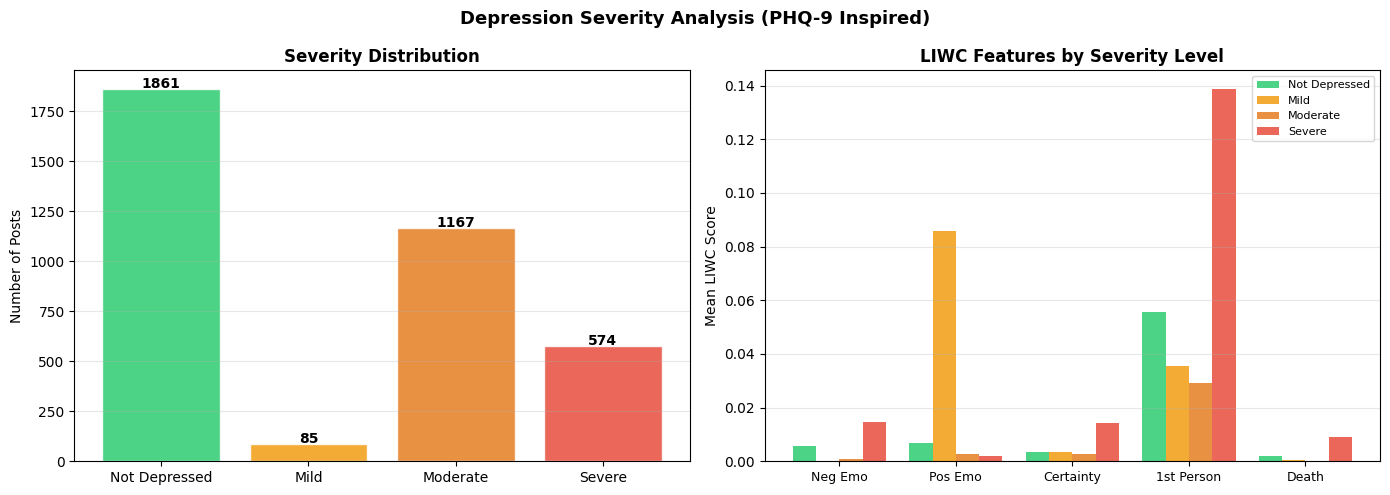

✅ Saved → severity_analysis.png

  Clinical Insight:
  Model provides actionable severity levels for clinicians
  Severe posts → immediate clinical attention needed
  Mild posts   → monitoring and early intervention


In [15]:
# ══════════════════════════════════════════════════════════════════
# STEP 13 — SEVERITY DETECTION (Mild / Moderate / Severe)
# Maps LIWC scores to PHQ-9 clinical depression scale
# ══════════════════════════════════════════════════════════════════
print("=" * 65)
print("  SEVERITY DETECTION — PHQ-9 Inspired Classification")
print("  Not Depressed | Mild | Moderate | Severe")
print("=" * 65)
print()

def assign_severity(text, liwc_vec, pred_prob):
    """
    Assign depression severity based on:
    - Model probability (P(depressed))
    - LIWC clinical signals
    - Text characteristics
    Maps to PHQ-9 inspired 4-level scale
    """
    if pred_prob < 0.40:
        return 0, 'Not Depressed'

    # Clinical severity score from LIWC
    neg_emo  = liwc_vec[0]   # negative emotion
    pos_emo  = liwc_vec[1]   # positive emotion (inverse)
    certainty= liwc_vec[3]   # absolute thinking
    first_p  = liwc_vec[4]   # self-focus
    death    = liwc_vec[5]   # death words
    anxiety  = liwc_vec[12]  # anxiety
    anger    = liwc_vec[13]  # anger

    # Clinical severity formula (PHQ-9 inspired)
    severity_score = (
        neg_emo  * 3.0 +   # strongest depression indicator
        first_p  * 1.5 +   # self-focus
        certainty* 2.0 +   # black/white thinking
        death    * 4.0 +   # most severe signal
        anxiety  * 1.5 +
        anger    * 1.0 -
        pos_emo  * 2.0     # positive emotion reduces severity
    )

    # Combine with model probability
    combined = 0.6 * pred_prob + 0.4 * min(severity_score * 2, 1.0)

    if combined < 0.55:
        return 1, 'Mild'
    elif combined < 0.75:
        return 2, 'Moderate'
    else:
        return 3, 'Severe'

# Apply to test set
severity_preds = []
severity_labels_text = []

for i in range(len(X_test)):
    sev_num, sev_text = assign_severity(
        X_test[i],
        lw_test[i],
        float(test_probs[i]))
    severity_preds.append(sev_num)
    severity_labels_text.append(sev_text)

severity_counts = {0:0, 1:0, 2:0, 3:0}
for s in severity_preds:
    severity_counts[s] += 1

print("  Severity Distribution in Test Set:")
print(f"  Not Depressed : {severity_counts[0]:>4} ({severity_counts[0]/len(severity_preds)*100:.1f}%)")
print(f"  Mild          : {severity_counts[1]:>4} ({severity_counts[1]/len(severity_preds)*100:.1f}%)")
print(f"  Moderate      : {severity_counts[2]:>4} ({severity_counts[2]/len(severity_preds)*100:.1f}%)")
print(f"  Severe        : {severity_counts[3]:>4} ({severity_counts[3]/len(severity_preds)*100:.1f}%)")
print()

# Severity distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Depression Severity Analysis (PHQ-9 Inspired)',
             fontsize=13, fontweight='bold')

# Plot 1: Severity distribution
labels_sev = ['Not Depressed', 'Mild', 'Moderate', 'Severe']
counts_sev  = [severity_counts[i] for i in range(4)]
colors_sev  = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(labels_sev, counts_sev, color=colors_sev, alpha=0.85, edgecolor='white')
axes[0].set_title('Severity Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
for i, (v, c) in enumerate(zip(counts_sev, colors_sev)):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: LIWC features by severity
sev_liwc = {s: [] for s in range(4)}
for i, s in enumerate(severity_preds):
    sev_liwc[s].append(lw_test[i])

feature_names = ['Neg Emo', 'Pos Emo', 'Certainty', '1st Person', 'Death']
feat_idx      = [0, 1, 3, 4, 5]
x_sev = np.arange(len(feature_names))
w_sev = 0.2

for si, (sev, col, lbl) in enumerate(zip(
    [0,1,2,3], colors_sev, labels_sev)):
    if sev_liwc[sev]:
        arr = np.array(sev_liwc[sev])
        means = arr[:, feat_idx].mean(axis=0)
        axes[1].bar(x_sev + si*w_sev - 1.5*w_sev,
                    means, w_sev, label=lbl.replace('\n',' '),
                    color=col, alpha=0.85)

axes[1].set_xticks(x_sev)
axes[1].set_xticklabels(feature_names, fontsize=9)
axes[1].set_title('LIWC Features by Severity Level', fontweight='bold')
axes[1].set_ylabel('Mean LIWC Score')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/severity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → severity_analysis.png")
print()
print("  Clinical Insight:")
print("  Model provides actionable severity levels for clinicians")
print("  Severe posts → immediate clinical attention needed")
print("  Mild posts   → monitoring and early intervention")
print("=" * 65)


## STEP 11 — Save Results for NB3

In [16]:
model_results = {
    'test_preds'  : np.array(test_preds),
    'test_true'   : np.array(test_true),
    'test_probs'  : np.array(test_probs),
    'test_attn'   : np.array(test_attn),
    'test_acc'    : float(test_acc),
    'test_f1'     : float(test_f1),
    'test_prec'   : float(test_prec),
    'test_rec'    : float(test_rec),
    'test_auc'    : float(test_auc),
    'test_kappa'  : float(test_kappa),
    'model_state' : best_weights if best_weights is not None else model.state_dict(),
    'model_name'  : MODEL_NAME,
    'history'     : history,
    'n_liwc'      : N_LIWC,
    # ── NEW: zero-shot + severity ──
    'zero_shot'     : zero_shot_results if 'zero_shot_results' in dir() else None,
    'severity_preds': severity_preds    if 'severity_preds'    in dir() else None,
    'cv_f1_mean'    : float(np.mean(cv_f1s))  if 'cv_f1s'  in dir() else None,
    'cv_f1_std'     : float(np.std(cv_f1s))   if 'cv_f1s'  in dir() else None,
    'cv_auc_mean'   : float(np.mean(cv_aucs)) if 'cv_aucs' in dir() else None,
    # ── NEW: cross-validation results ──
    'cv_f1_mean'  : float(np.mean(cv_f1s)) if 'cv_f1s' in dir() else None,
    'cv_f1_std'   : float(np.std(cv_f1s))  if 'cv_f1s' in dir() else None,
    'cv_auc_mean' : float(np.mean(cv_aucs)) if 'cv_aucs' in dir() else None,
}

RESULTS_PATH = '/kaggle/working/model_results.pkl'
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(model_results, f)

sz = os.path.getsize(RESULTS_PATH) / (1024 * 1024)
print("=" * 55)
print("   ✅ NOTEBOOK 2 COMPLETE!")
print("=" * 55)
print(f"   model_results.pkl  ({sz:.1f} MB)")
print(f"   mentalbert_best.pt")
print(f"   training_curves.png")
print(f"   confusion_roc.png")
print()
if 'cv_f1s' in dir():
    print(f"   CV Results: F1={np.mean(cv_f1s):.4f}±{np.std(cv_f1s):.4f}  AUC={np.mean(cv_aucs):.4f}±{np.std(cv_aucs):.4f}")
print()
print("   📌 Next Steps for NB3:")
print("   1. Output tab → Download model_results.pkl")
print("   2. Also download mentalbert_best.pt")
print("   3. Upload both → NB3 Input section")
print("   4. Run NB3!")
print("=" * 55)


   ✅ NOTEBOOK 2 COMPLETE!
   model_results.pkl  (422.1 MB)
   mentalbert_best.pt
   training_curves.png
   confusion_roc.png

   CV Results: F1=0.8181±0.0057  AUC=0.9150±0.0032

   📌 Next Steps for NB3:
   1. Output tab → Download model_results.pkl
   2. Also download mentalbert_best.pt
   3. Upload both → NB3 Input section
   4. Run NB3!
